# Density Comparison in different Discipline Groups, Age Groups and Gender

#### Data loading


In [ ]:
from lib import util
from lib import plotting_style as plt
import pandas as pd
import numpy as np
#import lib.plotting_style as plt
import seaborn as sns
import lib.help_functions as hp
#import tueplots as tue

# data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\final_data_iaaf_scores_neu.csv') 
data = util.load_data()

data.head()


,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,group
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211.0,Sprint
1,2017,W,Frauen,100 m,11.06,1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187.0,Sprint
2,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169.0,Sprint
3,2017,W,Frauen,100 m,11.24,0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148.0,Sprint
4,2017,W,Frauen,100 m,11.25,1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146.0,Sprint


#### Group determiantions

In [2]:
# The number of top entries to collect
num_entries = 40

# Exclude outliers that are not explainable

data = data[(data["iaaf_score"] < 1380) & (data["iaaf_score"] > 20)]

# Define Discipline groups NOTE: Only the ones with clear data

mapping_dict = {
    **{d: 'Run' for d in ['800 m', '1500 m', '3000 m', '5000 m']},
    **{d: 'Sprint' for d in ['100 m', '200 m', '400 m', '400m Huerden']},
    **{d: 'Throw' for d in ['Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf']}, 
    **{d: 'Jump' for d in ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']}
}
data['disziplingruppe'] = data['disziplin'].map(mapping_dict)
data = data.dropna(subset=['disziplingruppe'])

#Define Adult age group
data['altersklasse'] = data['altersklasse'].replace({'Maenner': 'Adult', 'Frauen': 'Adult', '16': 'U16', '18': 'U18', '20': 'U20', '14': 'AK14'})

# Collect top entries
top_raw_all = hp.collect_top_entries(data, num_entries=num_entries)

### Plot 1: Differences for ranks 2001-2004 to 2021-2024

In [3]:
from scipy import stats
# Parameters
ranks = range(1, num_entries + 1)

# Store all results
results_std_mean = []
results_ranks_age = []
results_ranks_disc_age = []
results_ranks_all = []

# Unique events and genders
events = top_raw_all["disziplin"].unique()
genders = ["M", "W"]
age_groups = ["U18", "U20", "Adult"]

top_raw_all = top_raw_all[top_raw_all["altersklasse"].isin(age_groups)]

top_raw_all = top_raw_all.sort_values(["jahr", "iaaf_score"], ascending=[True, False])

top_raw_all['rank'] = top_raw_all.groupby(["disziplin", "jahr", "geschlecht", "altersklasse"])["iaaf_score"].rank(ascending=False, method='first')

grouped = top_raw_all.groupby(["disziplingruppe", "geschlecht", "altersklasse"])

# RANKS AND MEAN+STD FOR AGE GROUP AND DISCIPLINE GROUPS

for (dis_group, gender, age), subgroup in grouped:

    for r in range(1, num_entries+1):
        start_rank_vals = []
        end_rank_vals = []

        for event in subgroup['disziplin'].unique():
            subsub = subgroup[subgroup['disziplin'] == event]
            S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")

            start_rank_vals.append(S_gr.loc[2001:2004, r].mean())
            end_rank_vals.append(S_gr.loc[2021:2024, r].mean())
        
        mean_start_r = np.mean(start_rank_vals)
        mean_end_r = np.mean(end_rank_vals)
        diff_r = (mean_end_r - mean_start_r) / mean_start_r * 100

        results_ranks_disc_age.append({
            "Group": dis_group,
            "geschlecht": gender,
            "altersklasse": age,
            "mean_diff_perc": diff_r,
            "rank": r
        })

    start_values_pool = []
    end_values_pool = []

    for event in subgroup['disziplin'].unique():
        subsub = subgroup[subgroup['disziplin'] == event]
        S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")
        
        start = S_gr.loc[2001:2004].values.flatten()
        end = S_gr.loc[2021:2024].values.flatten()

        start_values_pool.extend(start[~np.isnan(start)])
        end_values_pool.extend(end[~np.isnan(end)])


    mean_diff = (np.mean(end_values_pool) - np.mean(start_values_pool)) / np.mean(start_values_pool) * 100
    std_diff = (np.std(end_values_pool) - np.std(start_values_pool)) / np.std(start_values_pool) * 100
    
    results_std_mean.append({
        "Group": dis_group,
        "geschlecht": gender,
        "altersklasse": age,
        "mean_diff_perc": mean_diff,
        "std_diff_perc": std_diff
    })

results_std_mean = pd.DataFrame(results_std_mean)

results_ranks_disc_age = pd.DataFrame(results_ranks_disc_age)

# ONLY FOR AGE GROUPS

grouped_age = top_raw_all.groupby(["geschlecht", "altersklasse"])

for (gender, age), subgroup in grouped_age:
    
    for r in range(1, num_entries+1):
        start_rank_vals = []
        end_rank_vals = []

        for event in subgroup['disziplin'].unique():
            subsub = subgroup[subgroup['disziplin'] == event]
            subsub = subsub.copy()
            subsub['rank'] = subsub.groupby("jahr")["iaaf_score"].rank(ascending=False, method='first')
            S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")
            
            start_rank_vals.append(S_gr.loc[2001:2004, r].mean())
            end_rank_vals.append(S_gr.loc[2021:2024, r].mean())

        mean_start_r = np.mean(start_rank_vals)
        mean_end_r = np.mean(end_rank_vals)
        diff_r = (mean_end_r - mean_start_r) / mean_start_r * 100

        results_ranks_age.append({
            "geschlecht": gender,
            "altersklasse": age,
            "mean_diff_perc": diff_r,
            "rank": r
        })

results_ranks_age = pd.DataFrame(results_ranks_age)

# RANKS FOR ALL DATA

for r in range(1, num_entries+1):
        start_rank_vals = []
        end_rank_vals = []

        for event in top_raw_all['disziplin'].unique():
            subsub = top_raw_all[top_raw_all['disziplin'] == event]
            S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")

            start_rank_vals.append(S_gr.loc[2001:2004, r].mean())
            end_rank_vals.append(S_gr.loc[2021:2024, r].mean())
        
        mean_start_r = np.mean(start_rank_vals)
        mean_end_r = np.mean(end_rank_vals)
        diff_r = (mean_end_r - mean_start_r) / mean_start_r * 100

        results_ranks_all.append({
            "mean_diff_perc": diff_r,
            "rank": r
        })

results_ranks_all = pd.DataFrame(results_ranks_all)


## Plotting: Standard Deviation and Mean Evolution

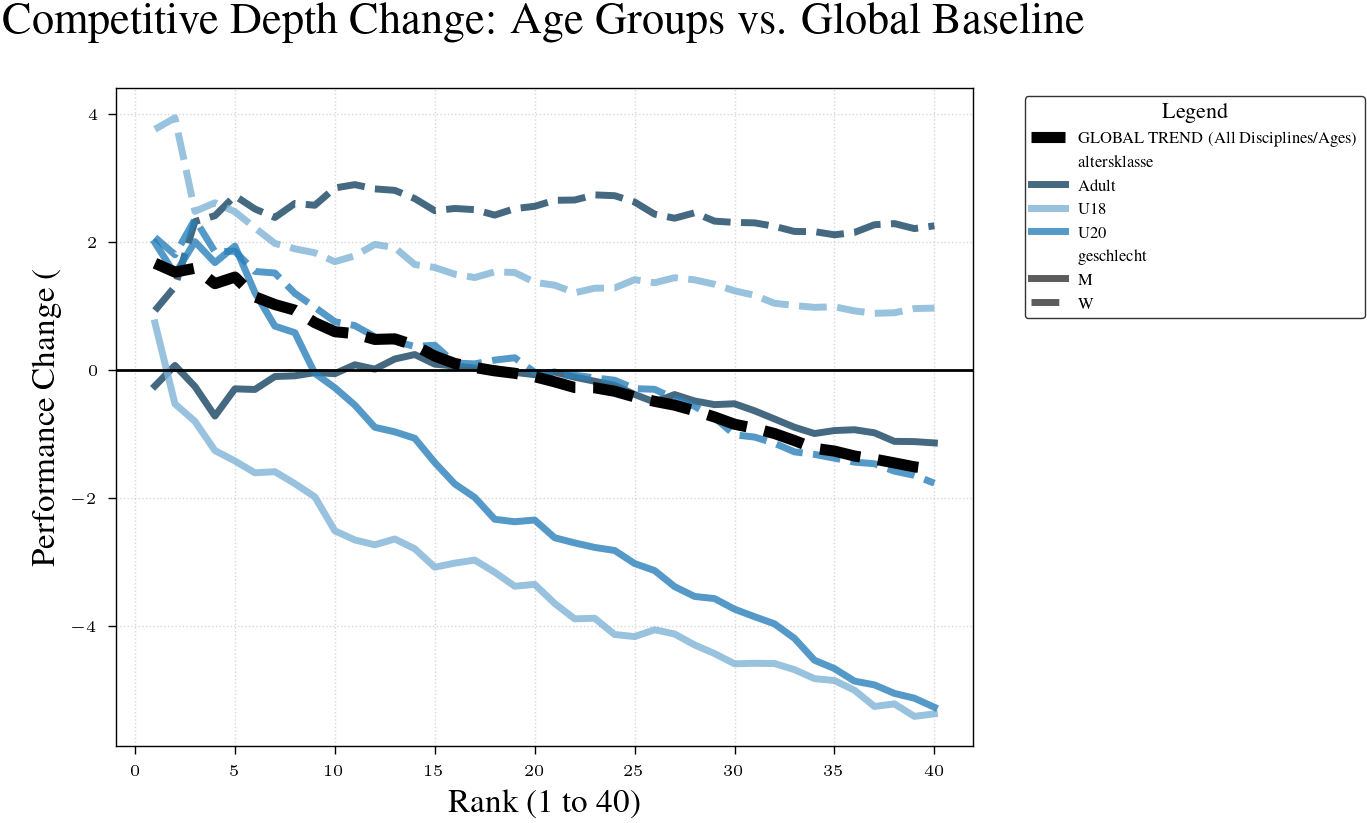

In [4]:

# 1. Global Trend
sns.lineplot(
    data=results_ranks_all,
    x="rank", y="mean_diff_perc",
    color="black", linewidth=4, linestyle="--",
    label="GLOBAL TREND (All Disciplines/Ages)",
    zorder=5  # Keep it on top
)

# 2. Plot Age & Gender specific trends (results_ranks_age)
# This uses the data aggregated by age and gender across all disciplines
sns.lineplot(
    data=results_ranks_age, 
    x="rank", y="mean_diff_perc", 
    hue="altersklasse", 
    style="geschlecht",
    palette={"U18": "#7fb3d5", "U20": "#2980b9", "Adult": "#154360"},
    linewidth=2.5,
    alpha=0.8
)

# Formatting
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title("Competitive Depth Change: Age Groups vs. Global Baseline", fontsize=16, pad=20)
plt.ylabel("Performance Change (%)", fontsize=12)
plt.xlabel("Rank (1 to 40)", fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.tight_layout()
plt.show()

/Users/maxwernz/development/Data Literacy/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


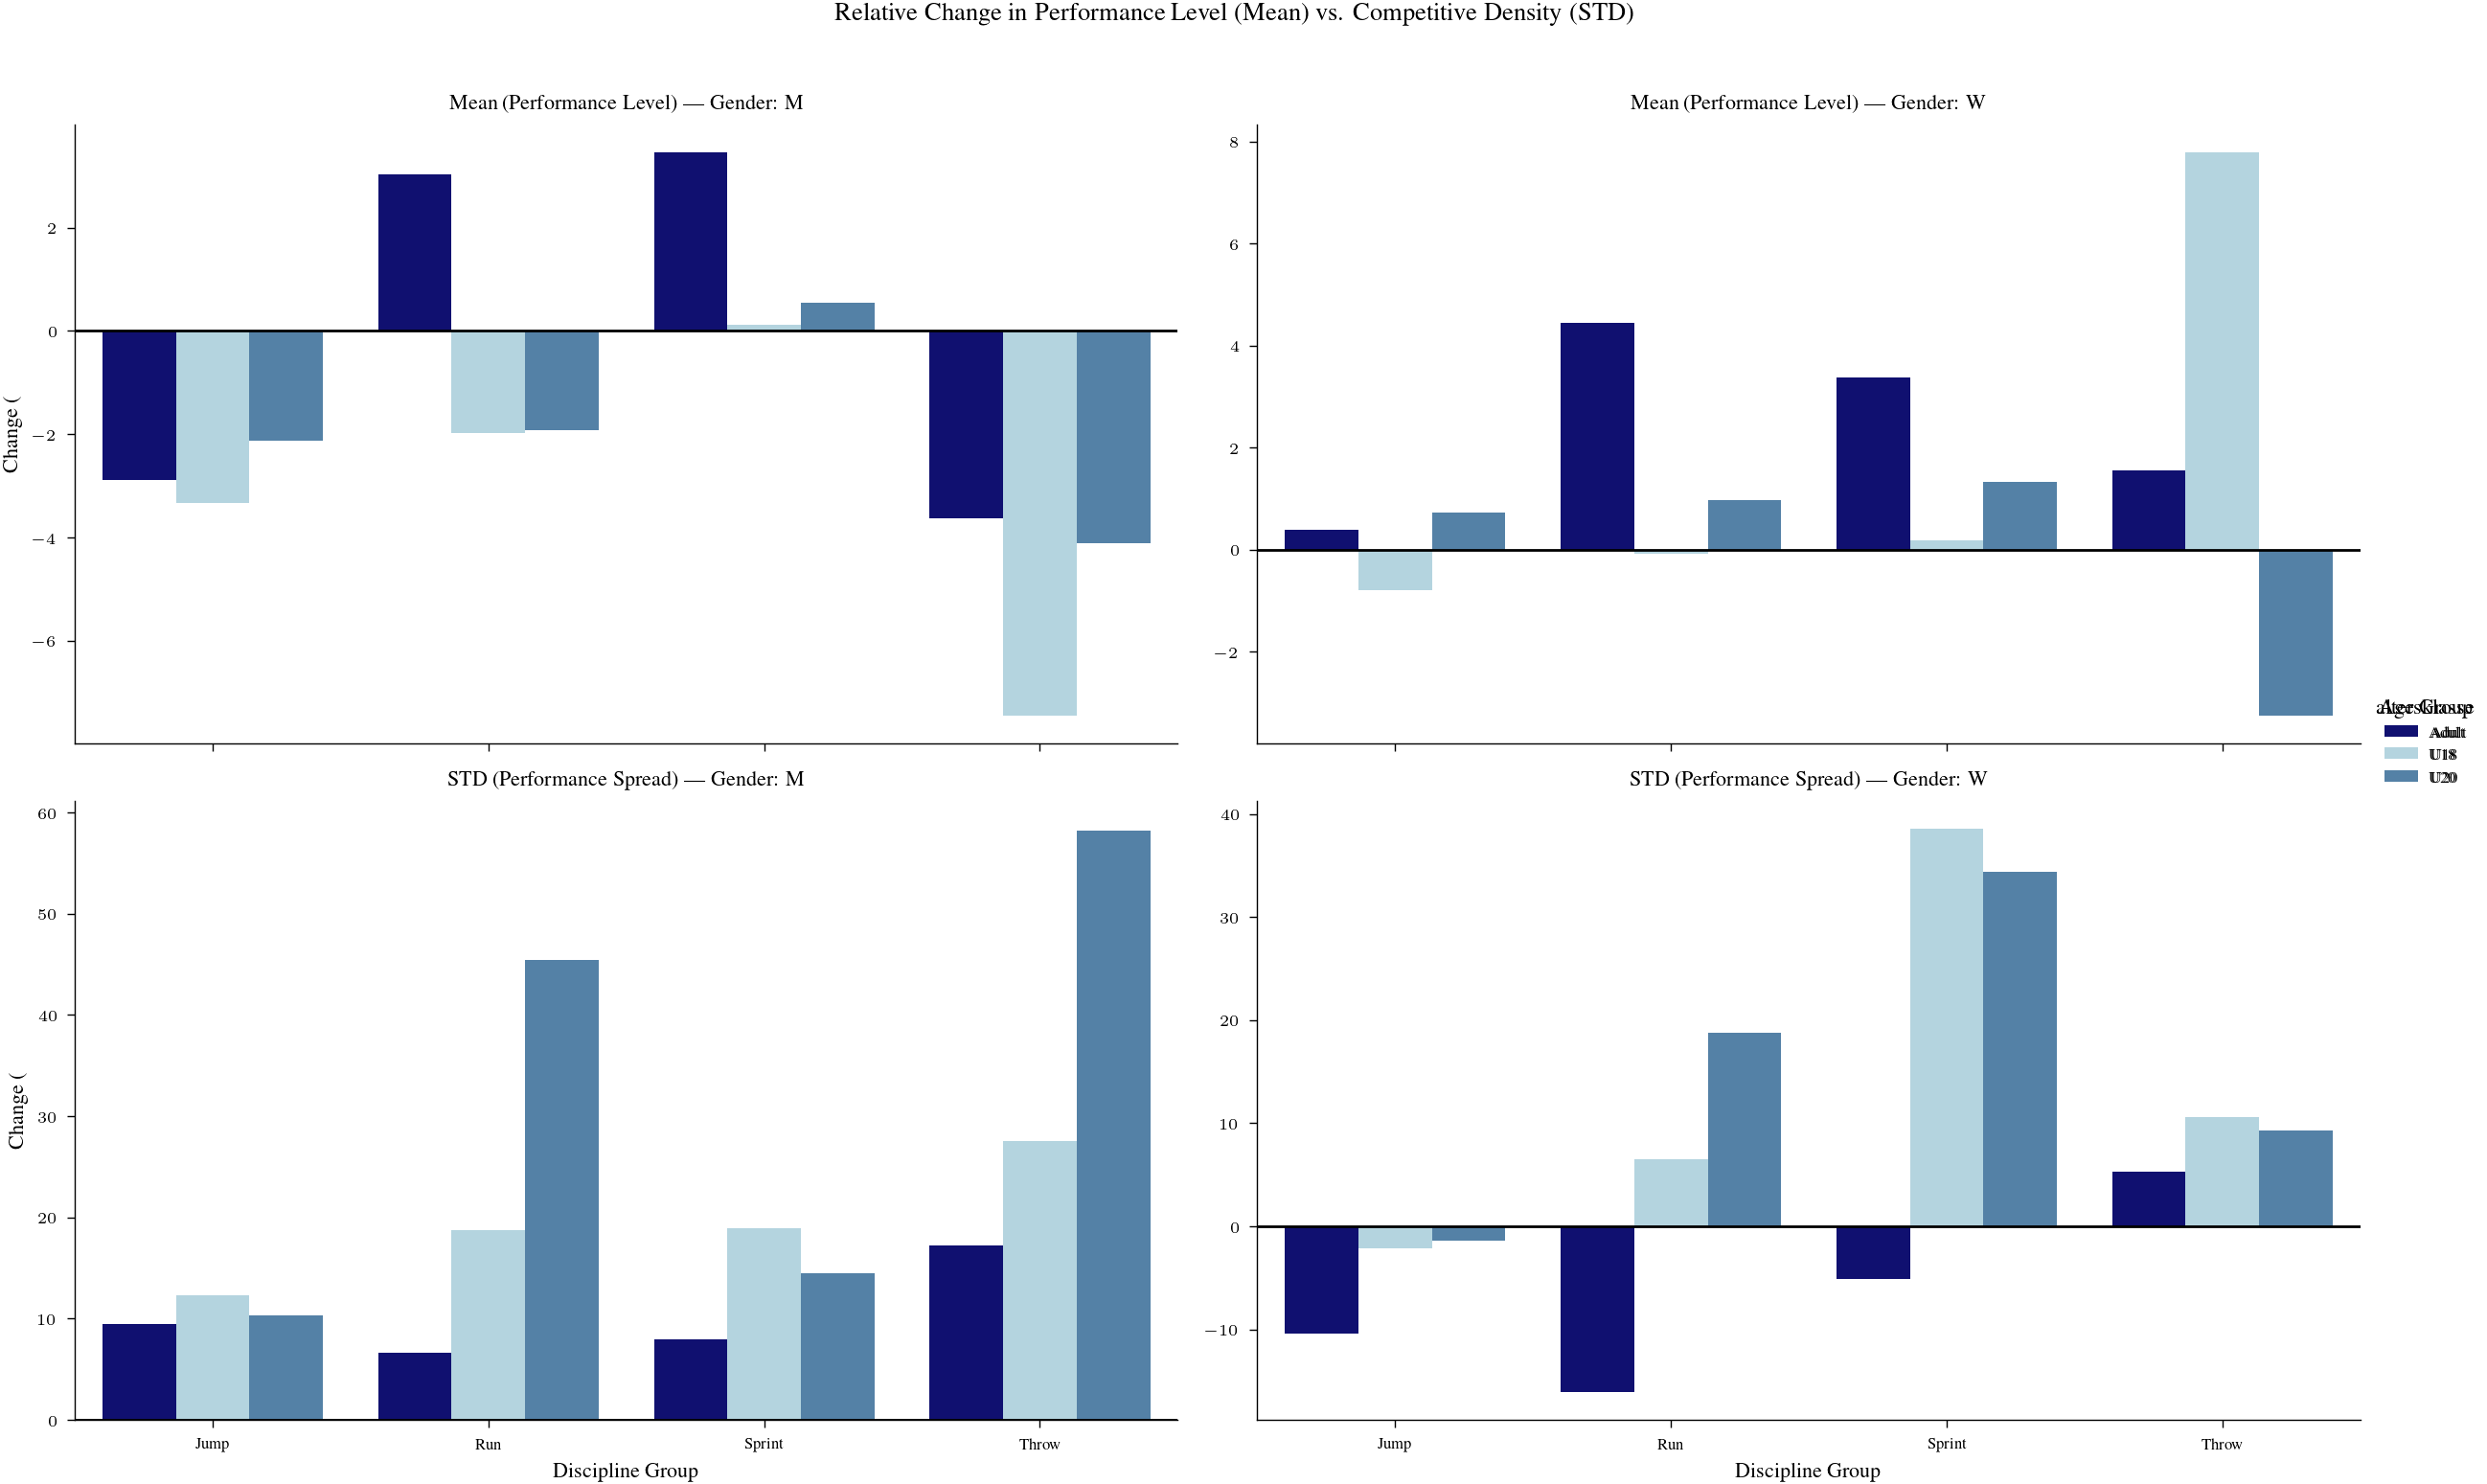

In [5]:
# 1. Melt the DataFrame to create a long format suitable for Seaborn
df_plot = results_std_mean.melt(
    id_vars=['Group', 'geschlecht', 'altersklasse'], 
    value_vars=['mean_diff_perc', 'std_diff_perc'],
    var_name='Metric', value_name='Change_Percent'
)

# 2. Rename for English labels
df_plot['Metric'] = df_plot['Metric'].replace({
    'mean_diff_perc': 'Mean (Performance Level)', 
    'std_diff_perc': 'STD (Performance Spread)'
})

# 3. Create the Plot
g = sns.catplot(
    data=df_plot, 
    x='Group', y='Change_Percent', 
    hue='altersklasse', col='geschlecht', row='Metric',
    kind='bar', 
    palette={"U18": "lightblue", "U20": "steelblue", "Adult": "navy"},
    height=4, aspect=1.5,
    sharey=False # Mean and STD have different scales
)

# 4. Styling
g.map(plt.axhline, y=0, color='black', linewidth=1)
g.set_titles("{row_name} | Gender: {col_name}")
g.set_axis_labels("Discipline Group", "Change (%)")
g.add_legend(title="Age Group")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Relative Change in Performance Level (Mean) vs. Competitive Density (STD)')

plt.show()

/Users/maxwernz/development/Data Literacy/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


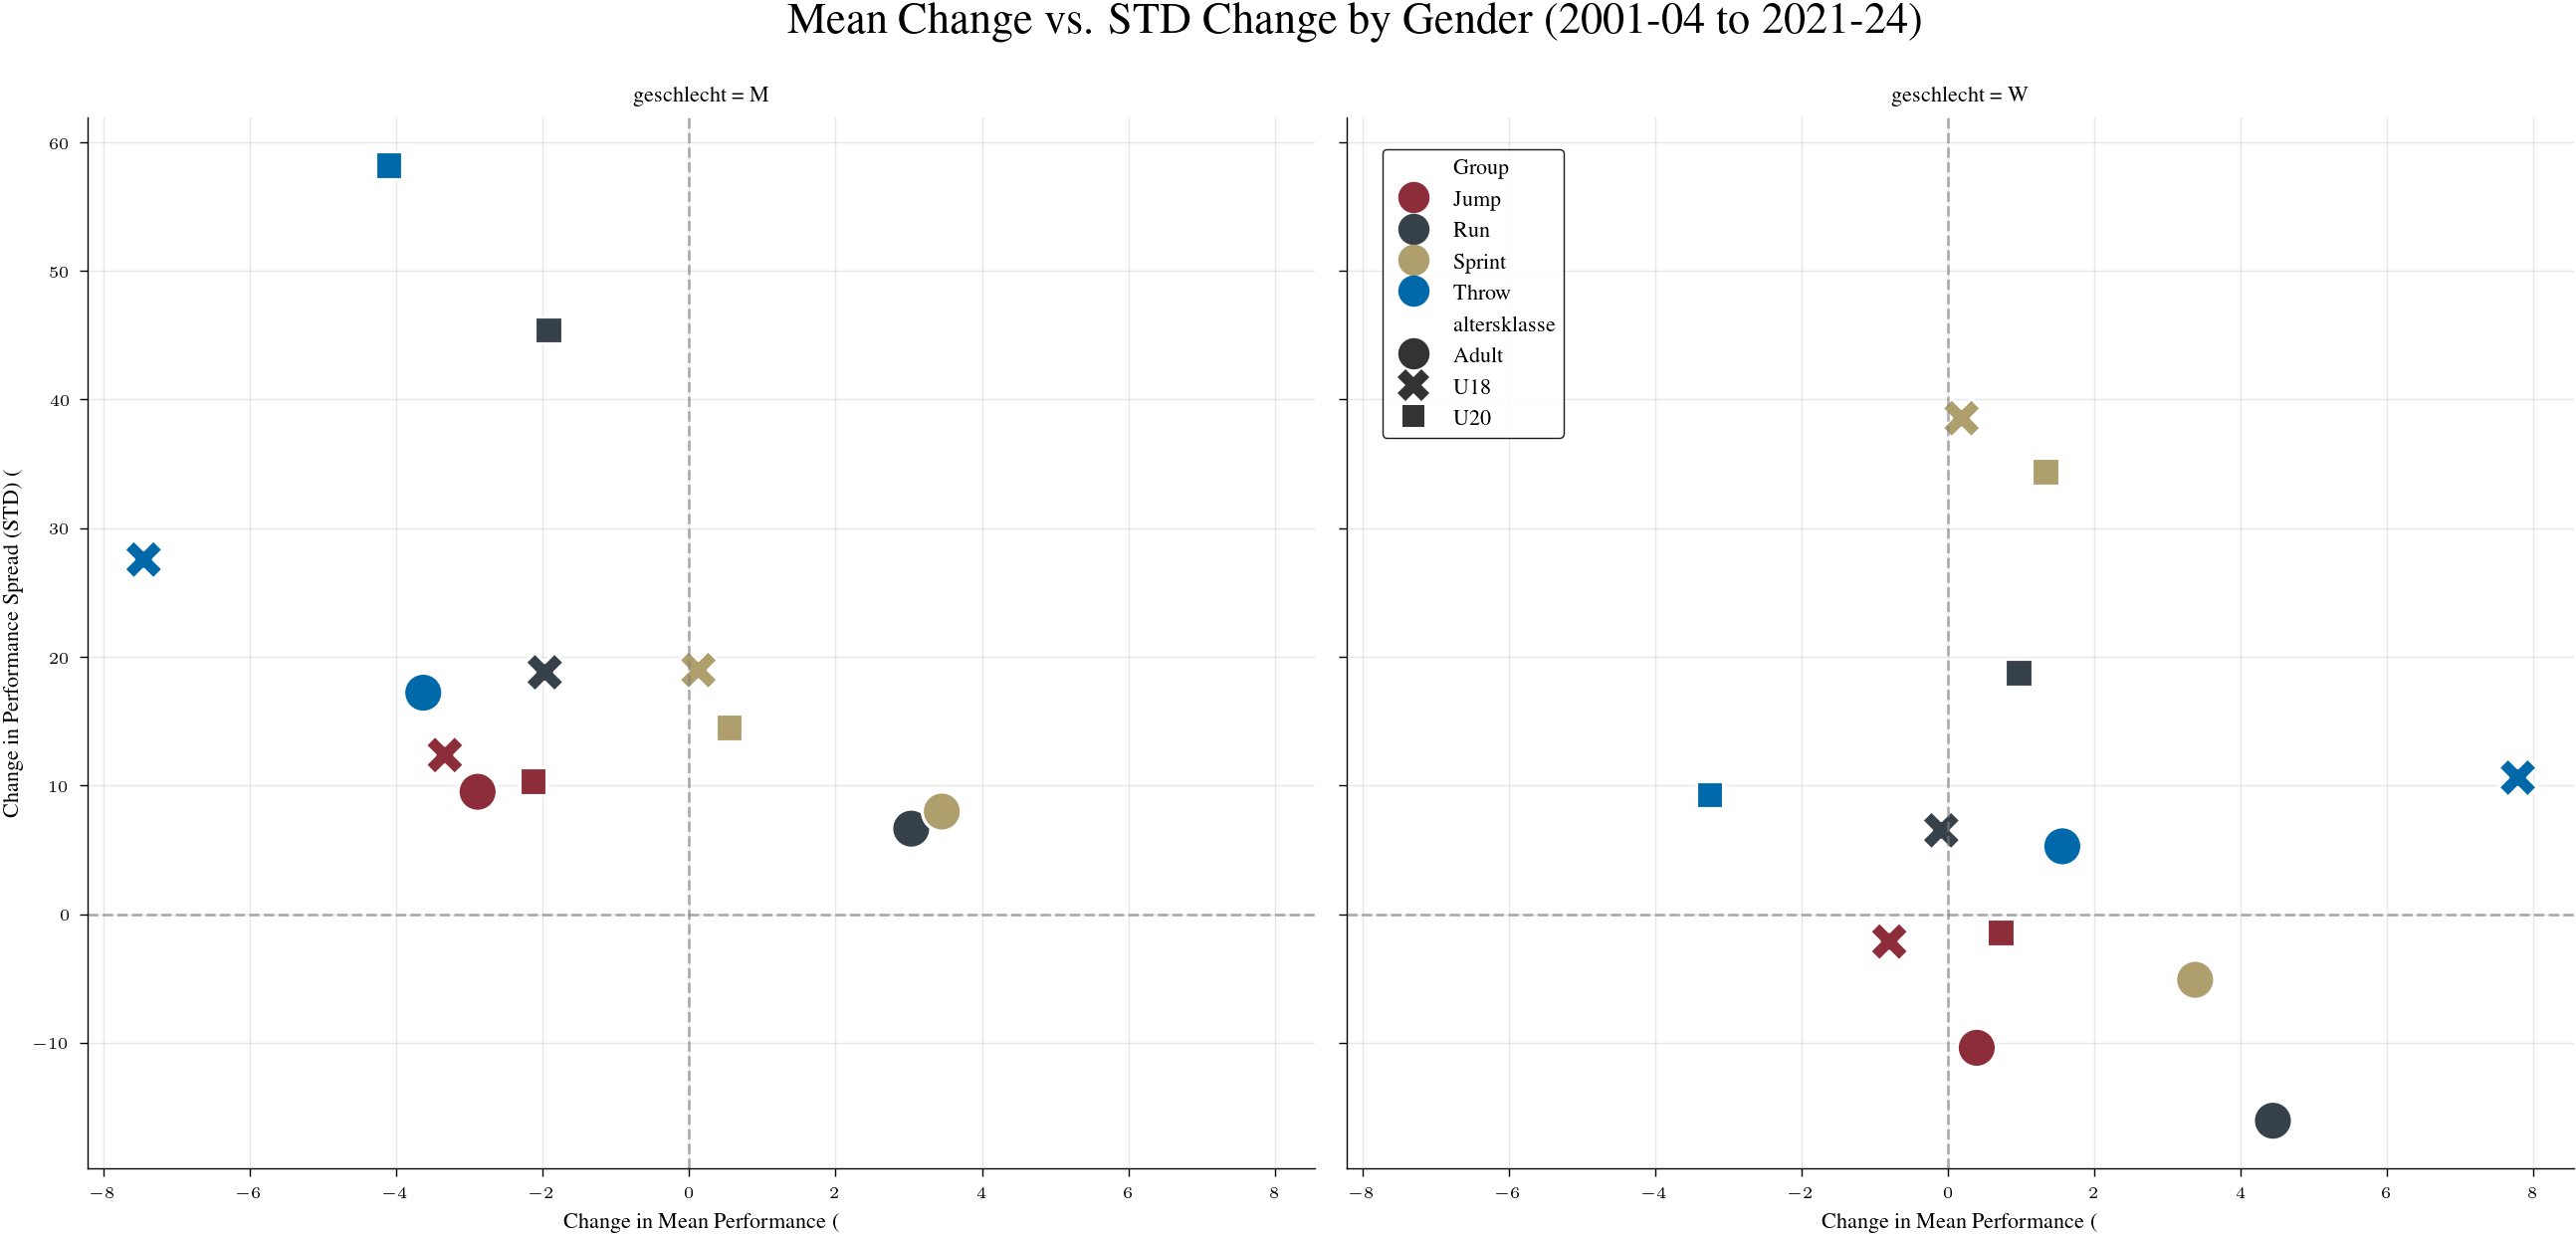

In [6]:

g = sns.relplot(
    data=results_std_mean, 
    x='mean_diff_perc', y='std_diff_perc', 
    hue='Group', 
    style='altersklasse', 
    col='geschlecht',  # Erzeugt zwei Spalten (M/W)
    s=200, 
    height=6, aspect=1.1,
    legend=True,
)

handles = g._legend.legend_handles
labels = [t.get_text() for t in g._legend.get_texts()]
g._legend.remove() # Das Original am rechten Rand entfernen

# 3. Legende manuell in den rechten Subplot setzen (g.axes[0, 1])
ax_right = g.axes[0, 1]
leg = ax_right.legend(
    handles=handles, 
    labels=labels, 
    loc='upper left', 
    bbox_to_anchor=(0.02, 0.98), 
    fontsize=8, 
    frameon=True, 
    framealpha=0.9,
    markerscale=0.8
)

# Referenzlinien (0-Achsen) für jeden Subplot hinzufügen
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.6)
    ax.grid(True, alpha=0.3)

# Titel und Beschriftung
g.set_axis_labels('Change in Mean Performance (%)', 'Change in Performance Spread (STD) (%)')
g.fig.suptitle('Mean Change vs. STD Change by Gender (2001-04 to 2021-24)', y=1.05, fontsize=16)

plt.show()

/Users/maxwernz/development/Data Literacy/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


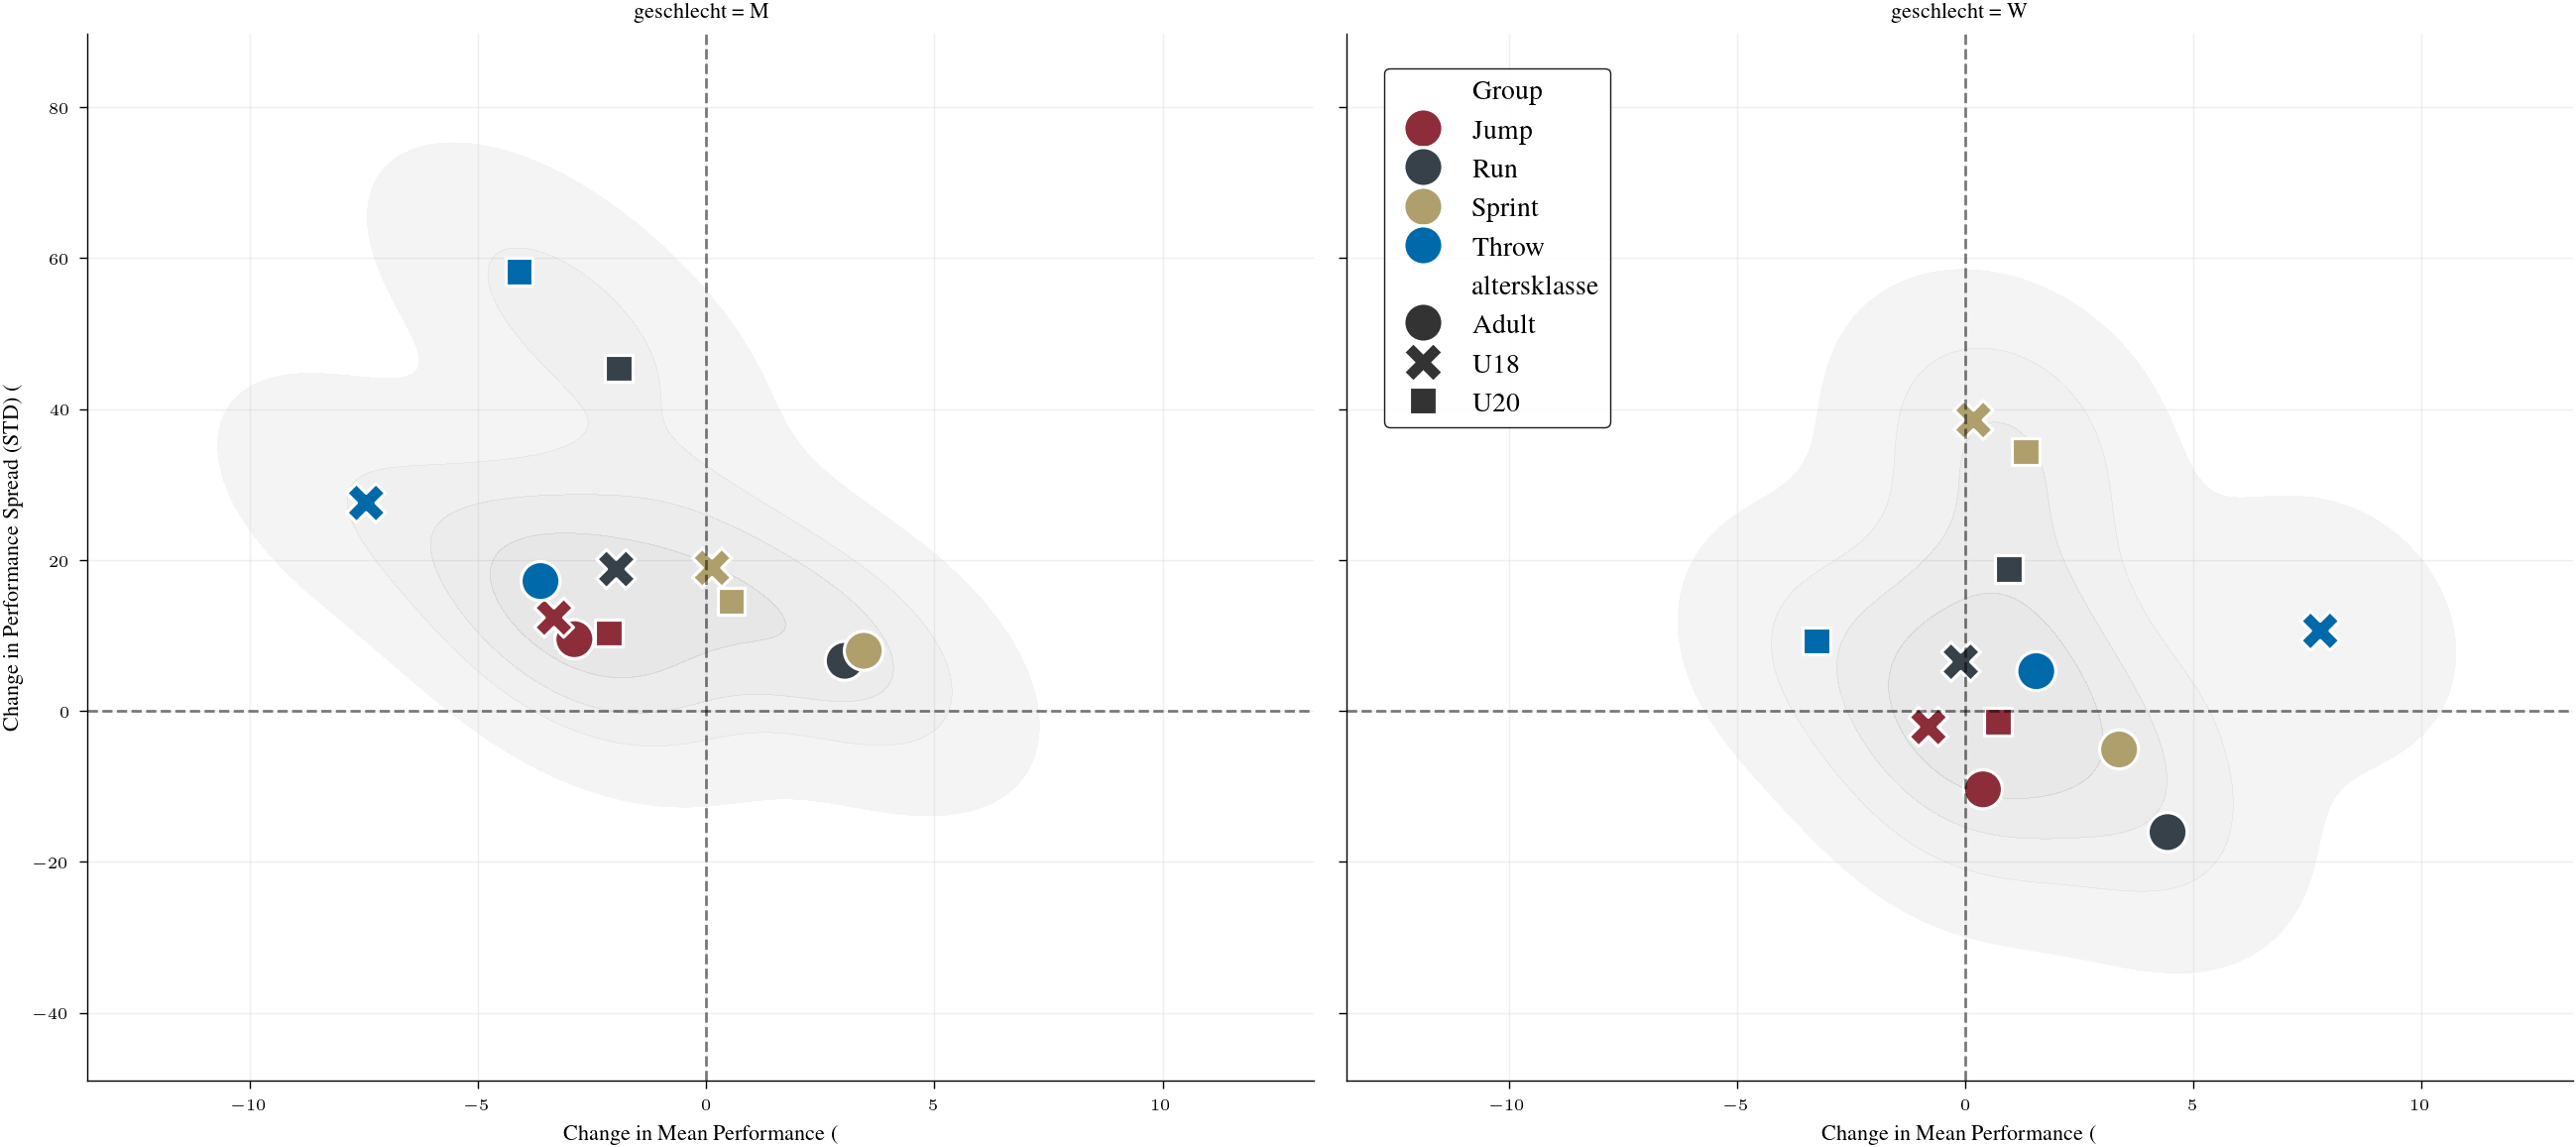

In [7]:

# Create the FacetGrid for Gender
g = sns.FacetGrid(results_std_mean, col="geschlecht", height=6, aspect=1.1)

# 1. Add the Density Contours first (in the background)
g.map_dataframe(sns.kdeplot, x='mean_diff_perc', y='std_diff_perc', 
                fill=True, alpha=0.15, levels=5, color="gray")

# 2. Add the individual Scatter points on top
g.map_dataframe(sns.scatterplot, x='mean_diff_perc', y='std_diff_perc', 
                hue='Group', style='altersklasse', s=200)

# 3. Add Reference Lines and Styling
for ax in g.axes.flat:
    ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.grid(True, alpha=0.2)

handles, labels = g.axes[0, 0].get_legend_handles_labels()

# 5. Legende in den RECHTEN Plot setzen
# Damit kein weißer Rand rechts entsteht, rufen wir g.add_legend() gar nicht erst auf
g.axes[0, 1].legend(
    handles=handles, 
    labels=labels, 
    loc='upper left', 
    bbox_to_anchor=(0.02, 0.98), 
    fontsize=8, 
    frameon=True, 
    framealpha=0.9,
    markerscale=0.8
)

# Wir setzen die Legende in den RECHTEN Plot (Index 1)
# loc='upper left' bezieht sich auf die Ecke der Legende
# bbox_to_anchor=(0.02, 0.98) ist die Position innerhalb des Plots
g.axes[0, 1].legend(handles=handles, labels=labels, loc='upper left', 
                   bbox_to_anchor=(0.02, 0.98), fontsize=10, 
                   frameon=True, framealpha=0.9)

g.set_axis_labels('Change in Mean Performance (%)', 'Change in Performance Spread (STD) (%)')
plt.show()

In [8]:
results_all_subgroups = []

for (dis, gender, age), subgroup in top_raw_all.groupby(["disziplin", "geschlecht", "altersklasse"]):

    for event in subgroup['disziplin'].unique():
        subsub = subgroup[subgroup['disziplin'] == event]
        S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")
        
        start = S_gr.loc[2001:2004].values.flatten()
        end = S_gr.loc[2021:2024].values.flatten()

        mean_diff = (np.mean(end) - np.mean(start)) / np.mean(start) * 100
        std_diff = (np.std(end) - np.std(start)) / np.std(start) * 100
        
        results_all_subgroups.append({
            "disziplin": dis,
            "geschlecht": gender,
            "altersklasse": age,
            "mean_diff_perc": mean_diff,
            "std_diff_perc": std_diff
        })

results_all_subgroups = pd.DataFrame(results_all_subgroups)

/Users/maxwernz/development/Data Literacy/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


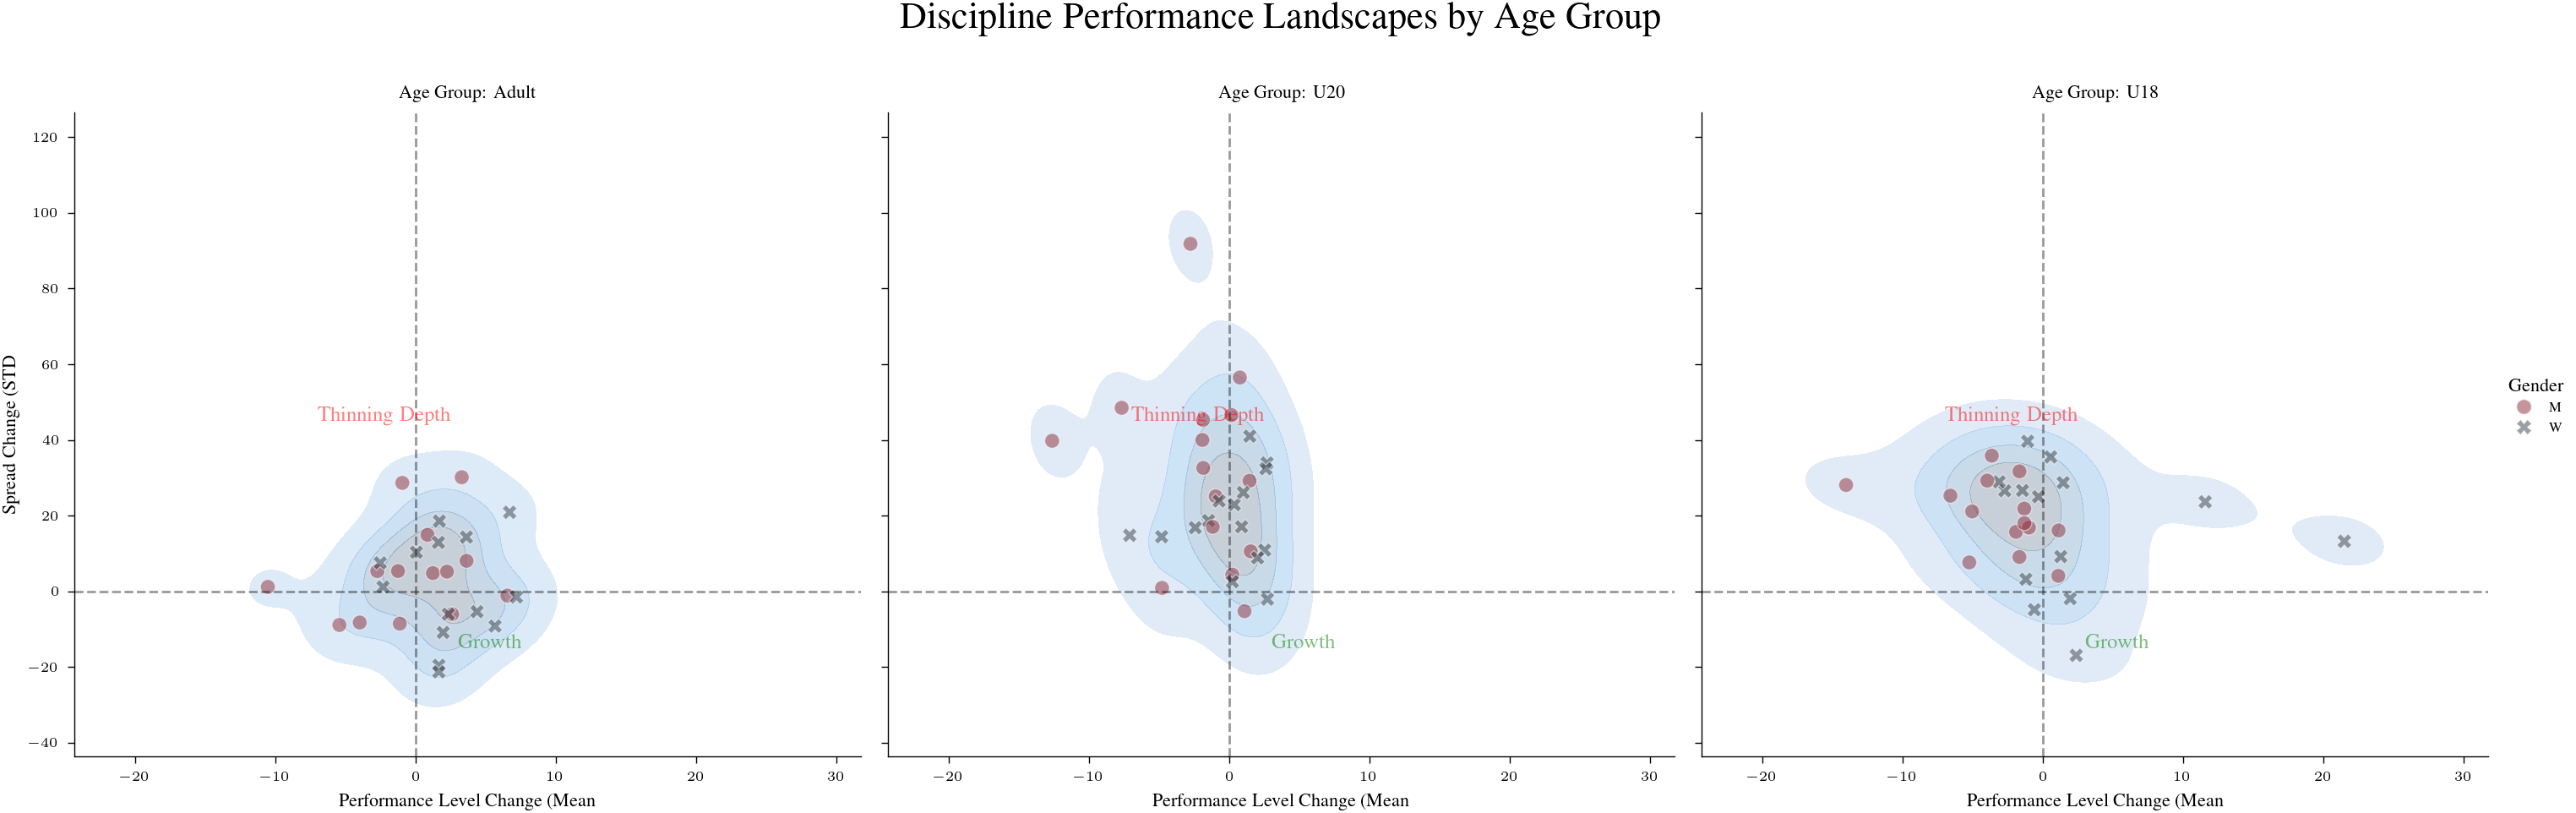

In [9]:


# 1. Create the FacetGrid
# We order them Adult -> U20 -> U18 to show the logical progression
g = sns.FacetGrid(
    results_all_subgroups, 
    col="altersklasse", 
    col_order=["Adult", "U20", "U18"],
    height=5, 
    aspect=1,
    sharex=True, 
    sharey=True
)

# 2. Map the KDE (Density Cloud) to each subplot
g.map_dataframe(
    sns.kdeplot, 
    x='mean_diff_perc', 
    y='std_diff_perc',
    fill=True, 
    alpha=0.3, 
    levels=5, 
    thresh=0.1, 
    color="steelblue"
)

# 3. Map individual discipline points on top
g.map_dataframe(
    sns.scatterplot, 
    x='mean_diff_perc', 
    y='std_diff_perc', 
    hue='geschlecht', 
    style='geschlecht',
    alpha=0.5, 
    s=40
)

# 4. Add reference lines and labels to each plot
for ax in g.axes.flat:
    # 0-Reference lines
    ax.axhline(0, color='black', linestyle='--', alpha=0.4)
    ax.axvline(0, color='black', linestyle='--', alpha=0.4)
    
    # Optional: Visual "Quadrant" Hints
    ax.text(-7, 45, "Thinning Depth", color='red', alpha=0.5, fontsize=9)
    ax.text(3, -15, "Growth", color='green', alpha=0.5, fontsize=9)

# Final Styling
g.set_axis_labels("Performance Level Change (Mean %)", "Spread Change (STD %)")
g.set_titles(col_template="Age Group: {col_name}")
g.add_legend(title="Gender")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Discipline Performance Landscapes by Age Group', fontsize=16)

plt.show()

/Users/maxwernz/development/Data Literacy/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


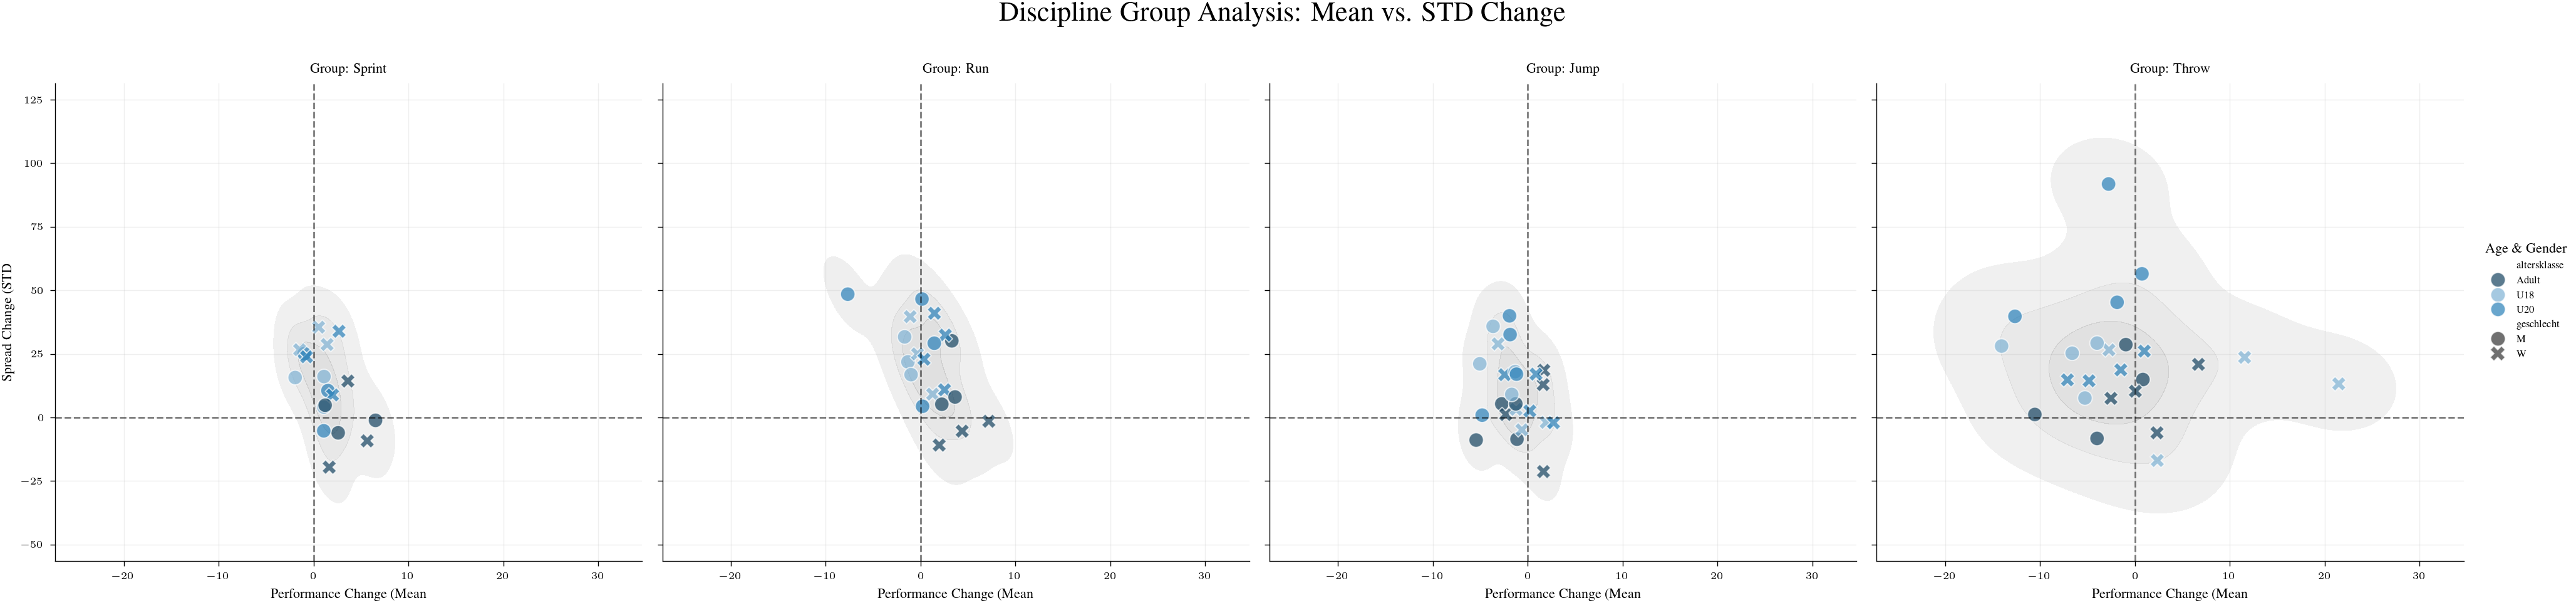

In [ ]:
import seaborn as sns
import lib.plotting_style as plt

# Add the Group column to your dataframe
results_all_subgroups['Group'] = results_all_subgroups['disziplin'].map(mapping_dict)

# Drop any rows that didn't have a mapping (optional, for safety)
df_all = results_all_subgroups.dropna(subset=['Group'])
# 1. Initialize the FacetGrid
# We use 'Group' for columns to see the 4 categories side-by-side
g = sns.FacetGrid(
    results_all_subgroups, 
    col="Group", 
    col_order=['Sprint', 'Run', 'Jump', 'Throw'],
    height=5, 
    aspect=1,
    sharex=True, 
    sharey=True
)

# 2. Map the Density (KDE) to show the 'mass' of each group
g.map_dataframe(
    sns.kdeplot, 
    x='mean_diff_perc', 
    y='std_diff_perc',
    fill=True, 
    alpha=0.2, 
    levels=4, 
    color="gray"
)

# 3. Map the individual data points
# Hue by age group shows the 'drift' within that specific discipline
g.map_dataframe(
    sns.scatterplot, 
    x='mean_diff_perc', 
    y='std_diff_perc', 
    hue='altersklasse', 
    style='geschlecht',
    palette={"U18": "#7fb3d5", "U20": "#2980b9", "Adult": "#154360"},
    s=70,
    alpha=0.7
)

# 4. Styling and Reference Lines
for ax in g.axes.flat:
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.2)

g.set_axis_labels("Performance Change (Mean %)", "Spread Change (STD %)")
g.set_titles(col_template="Group: {col_name}")
g.add_legend(title="Age \\& Gender")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Discipline Group Analysis: Mean vs. STD Change', fontsize=16)

plt.show()

# Including Statistical Tests

In [87]:
from scipy import stats

# List to store enhanced results
results_enhanced = []

for (dis_group, gender, age), subgroup in grouped:
    start_values_pool = []
    end_values_pool = []

    # Pooling raw scores for the two periods
    for event in subgroup['disziplin'].unique():
        subsub = subgroup[subgroup['disziplin'] == event]
        S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")
        
        start = S_gr.loc[2001:2004].values.flatten()
        end = S_gr.loc[2021:2024].values.flatten()

        start_values_pool.extend(start[~np.isnan(start)])
        end_values_pool.extend(end[~np.isnan(end)])

    # Convert to arrays
    s_pool = np.array(start_values_pool)
    e_pool = np.array(end_values_pool)

    if len(s_pool) > 1 and len(e_pool) > 1:
        # 1. Welch’s t-test for Mean
        t_stat, p_mean = stats.ttest_ind(e_pool, s_pool, equal_var=False)

        # 2. Levene’s test for Variance (Standard Deviation)
        # H0: The variances are equal. If p < 0.05, the spread has changed.
        _, p_std = stats.levene(e_pool, s_pool)

        # 3. Cohen's d for Effect Size
        n1, n2 = len(e_pool), len(s_pool)
        v1, v2 = np.var(e_pool, ddof=1), np.var(s_pool, ddof=1)
        pooled_sd = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
        cohen_d = (np.mean(e_pool) - np.mean(s_pool)) / pooled_sd if pooled_sd > 0 else 0

        # Calculations for percent change
        m_diff_perc = (np.mean(e_pool) - np.mean(s_pool)) / np.mean(s_pool) * 100
        s_diff_perc = (np.std(e_pool) - np.std(s_pool)) / np.std(s_pool) * 100

        results_enhanced.append({
            "Group": dis_group,
            "Gender": gender,
            "Age": age,
            "Mean_Diff_%": round(m_diff_perc, 2),
            "P_Val_Mean": round(p_mean, 4),
            "Cohen_d": round(cohen_d, 3),
            "STD_Diff_%": round(s_diff_perc, 2),
            "P_Val_STD": round(p_std, 4),
            "Interpretation": "Large" if abs(cohen_d) > 0.8 else "Med" if abs(cohen_d) > 0.5 else "Small"
        })

# Create and Print DataFrame
results_df = pd.DataFrame(results_enhanced)
print(results_df.to_string(index=False))

 Group Gender   Age  Mean_Diff_%  P_Val_Mean  Cohen_d  STD_Diff_%  P_Val_STD Interpretation
  Jump      M Adult        -2.89      0.0000   -0.377        9.51     0.1200          Small
  Jump      M   U18        -3.34      0.0000   -0.402       12.36     0.0029          Small
  Jump      M   U20        -2.13      0.0000   -0.272       10.32     0.0359          Small
  Jump      W Adult         0.39      0.3959    0.050      -10.39     0.0763          Small
  Jump      W   U18        -0.80      0.1224   -0.086       -2.13     0.1481          Small
  Jump      W   U20         0.72      0.1481    0.082       -1.41     0.1701          Small
   Run      M Adult         1.73      0.0000    0.241       12.15     0.0011          Small
   Run      M   U18        -1.97      0.0008   -0.233       18.80     0.0006          Small
   Run      M   U20        -1.92      0.0023   -0.172       45.42     0.0000          Small
   Run      W Adult         4.44      0.0000    0.719      -12.91     0.0028    

In [ ]:
import numpy as np
from scipy import stats

# 1. Initialize master pools for all raw scores
all_start_scores = []
all_end_scores = []

# 2. Iterate through your existing grouped object to pool raw data
# This ensures we extract the same ranks/years used in the sub-group analysis
for (dis_group, gender, age), subgroup in grouped:
    for event in subgroup['disziplin'].unique():
        subsub = subgroup[subgroup['disziplin'] == event]
        
        # Create the pivot table for this specific event
        S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")
        
        # Extract raw scores for the two 4-year windows
        start_period = S_gr.loc[2001:2004].values.flatten()
        end_period = S_gr.loc[2021:2024].values.flatten()

        # Remove NaNs and append to global arrays
        all_start_scores.extend(start_period[~np.isnan(start_period)])
        all_end_scores.extend(end_period[~np.isnan(end_period)])

# Convert to numpy arrays for calculation
s_all = np.array(all_start_scores)
e_all = np.array(all_end_scores)

# 3. Global Statistical Calculations
mean_s, mean_e = np.mean(s_all), np.mean(e_all)
std_s, std_e = np.std(s_all, ddof=1), np.std(e_all, ddof=1)

diff_mean = mean_e - mean_s
diff_std = std_e - std_s

# Welch's T-Test (Is the global mean shift non-random?)
t_stat, p_mean_global = stats.ttest_ind(e_all, s_all, equal_var=False)

# Levene's Test (Is the global spread/variance shift non-random?)
_, p_std_global = stats.levene(e_all, s_all)

# Cohen's d (The standardized magnitude of the shift)
n1, n2 = len(e_all), len(s_all)
v1, v2 = np.var(e_all, ddof=1), np.var(s_all, ddof=1)
pooled_sd = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
cohen_d_global = (mean_e - mean_s) / pooled_sd

# 4. Print Results
print("=== GLOBAL AGGREGATE ANALYSIS (ALL DATA) ===")
print(f"Total Scores Analyzed: {len(s_all) + len(e_all)}")
print(f"Global Mean Shift: {mean_s:.2f} -> {mean_e:.2f} ({((mean_e-mean_s)/mean_s)*100:+.2f}%)")
print(f"P-Value (Mean): {p_mean_global:.4e}")
print(f"Cohen's d: {cohen_d_global:.4f}")
print("-" * 40)
print(f"Global STD Shift: {std_s:.2f} -> {std_e:.2f} ({((std_e-std_s)/std_s)*100:+.2f}%)")
print(f"P-Value (STD): {p_std_global:.4e}")
print(f"Interpretation: {'Large' if abs(cohen_d_global) > 0.8 else 'Med' if abs(cohen_d_global) > 0.5 else 'Small' if abs(cohen_d_global) > 0.2 else 'Trivial'}")

=== GLOBAL AGGREGATE ANALYSIS (ALL DATA) ===
Total Scores Analyzed: 27560
Global Mean Shift: 904.60 -> 904.46 (-0.02%)
P-Value (Mean): 9.2185e-01
Cohen's d: -0.0012
----------------------------------------
Global STD Shift: 109.43 -> 123.69 (+13.03%)
P-Value (STD): 9.7428e-50
Interpretation: Trivial


In [90]:


results_dis = []

# Group by the specific discipline name
grouped_dis = top_raw_all.groupby(["disziplin", "geschlecht", "altersklasse"])

for (dis, gender, ag), subgroup in grouped_dis:
    # 1. Collect raw scores for the two eras
    S_gr = subgroup.pivot_table(index="jahr", columns="rank", values="iaaf_score")
    
    start_vals = S_gr.loc[2001:2004].values.flatten()
    end_vals = S_gr.loc[2021:2024].values.flatten()

    s_pool = np.array(start_vals)[~np.isnan(start_vals)]
    e_pool = np.array(end_vals)[~np.isnan(end_vals)]

    # We need a minimum amount of data to run a meaningful test
    if len(s_pool) > 8 and len(e_pool) > 8:
        # Welch's T-test (Mean)
        t_stat, p_mean = stats.ttest_ind(e_pool, s_pool, equal_var=False)
        # Levene's test (Spread)
        _, p_std = stats.levene(e_pool, s_pool)
        
        # Cohen's d (Effect Size)
        sd_pool = np.sqrt(((len(e_pool)-1)*np.var(e_pool, ddof=1) + (len(s_pool)-1)*np.var(s_pool, ddof=1)) / (len(e_pool)+len(s_pool)-2))
        d = (np.mean(e_pool) - np.mean(s_pool)) / sd_pool if sd_pool > 0 else 0
        
        results_dis.append({
            "Discipline": dis,
            "Gender": gender,
            "Age_Group": ag,
            "Mean_Diff_Perc": ((np.mean(e_pool) - np.mean(s_pool)) / np.mean(s_pool)) * 100,
            "STD_Diff_Perc": ((np.std(e_pool) - np.std(s_pool)) / np.std(s_pool)) * 100,
            "Cohen_d": d,
            "P_Value": p_mean,
            "Log_P": -np.log10(p_mean) if p_mean > 0 else 0,
            "P_Val_STD": p_std
        })

df_dis = pd.DataFrame(results_dis)

In [94]:
from scipy import stats
import numpy as np
import pandas as pd

# Parameters
ranks = range(1, num_entries + 1)
results_std_mean = []
results_ranks_age = []
results_ranks_disc_age = []
results_ranks_all = []

# Helper function to calculate Cohen's d
def calculate_cohens_d(x1, x2):
    n1, n2 = len(x1), len(x2)
    var1, var2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(x1) - np.mean(x2)) / pooled_std if pooled_std > 0 else 0

# --- 1. DISCIPLINE GROUPS, GENDER, & AGE ---
for (dis_group, gender, age), subgroup in grouped:
    # We pool raw values to perform meaningful tests
    all_start_obs = []
    all_end_obs = []

    for r in range(1, num_entries + 1):
        r_start_obs = []
        r_end_obs = []
        for event in subgroup['disziplin'].unique():
            subsub = subgroup[subgroup['disziplin'] == event]
            S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")
            
            s_vals = S_gr.loc[2001:2004, r].dropna().tolist()
            e_vals = S_gr.loc[2021:2024, r].dropna().tolist()
            
            r_start_obs.extend(s_vals)
            r_end_obs.extend(e_vals)
            all_start_obs.extend(s_vals)
            all_end_obs.extend(e_vals)

        # Statistical tests for specific RANKS within the group
        if len(r_start_obs) > 1 and len(r_end_obs) > 1:
            t_stat, p_val = stats.ttest_ind(r_end_obs, r_start_obs, equal_var=False)
            results_ranks_disc_age.append({
                "Group": dis_group, "geschlecht": gender, "altersklasse": age, "rank": r,
                "mean_diff_perc": (np.mean(r_end_obs) - np.mean(r_start_obs)) / np.mean(r_start_obs) * 100,
                "p_value": p_val, "cohens_d": calculate_cohens_d(r_end_obs, r_start_obs)
            })

    # Statistical tests for the WHOLE group (Mean & STD)
    if len(all_start_obs) > 1 and len(all_end_obs) > 1:
        t_stat, p_mean = stats.ttest_ind(all_end_obs, all_start_obs, equal_var=False)
        _, p_std = stats.levene(all_end_obs, all_start_obs)
        results_std_mean.append({
            "Group": dis_group, "geschlecht": gender, "altersklasse": age,
            "mean_diff_perc": (np.mean(all_end_obs) - np.mean(all_start_obs)) / np.mean(all_start_obs) * 100,
            "std_diff_perc": (np.std(all_end_obs) - np.std(all_start_obs)) / np.std(all_start_obs) * 100,
            "p_val_mean": p_mean, "p_val_std": p_std, "cohens_d": calculate_cohens_d(all_end_obs, all_start_obs)
        })

# --- 2. AGE GROUPS ONLY ---
grouped_age = top_raw_all.groupby(["geschlecht", "altersklasse"])
for (gender, age), subgroup in grouped_age:
    for r in range(1, num_entries + 1):
        r_start_obs, r_end_obs = [], []
        for event in subgroup['disziplin'].unique():
            subsub = subgroup[subgroup['disziplin'] == event].copy()
            subsub['rank'] = subsub.groupby("jahr")["iaaf_score"].rank(ascending=False, method='first')
            S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")
            r_start_obs.extend(S_gr.loc[2001:2004, r].dropna().tolist())
            r_end_obs.extend(S_gr.loc[2021:2024, r].dropna().tolist())

        if len(r_start_obs) > 1 and len(r_end_obs) > 1:
            t_stat, p_val = stats.ttest_ind(r_end_obs, r_start_obs, equal_var=False)
            results_ranks_age.append({
                "geschlecht": gender, "altersklasse": age, "rank": r,
                "mean_diff_perc": (np.mean(r_end_obs) - np.mean(r_start_obs)) / np.mean(r_start_obs) * 100,
                "p_value": p_val, "cohens_d": calculate_cohens_d(r_end_obs, r_start_obs)
            })

# --- 3. ALL DATA (BY RANK) ---
for r in range(1, num_entries + 1):
    r_start_obs, r_end_obs = [], []
    for event in top_raw_all['disziplin'].unique():
        subsub = top_raw_all[top_raw_all['disziplin'] == event]
        S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")
        r_start_obs.extend(S_gr.loc[2001:2004, r].dropna().tolist())
        r_end_obs.extend(S_gr.loc[2021:2024, r].dropna().tolist())

    if len(r_start_obs) > 1 and len(r_end_obs) > 1:
        t_stat, p_val = stats.ttest_ind(r_end_obs, r_start_obs, equal_var=False)
        results_ranks_all.append({
            "rank": r, "mean_diff_perc": (np.mean(r_end_obs) - np.mean(r_start_obs)) / np.mean(r_start_obs) * 100,
            "p_value": p_val, "cohens_d": calculate_cohens_d(r_end_obs, r_start_obs)
        })

# Final DataFrames
results_std_mean = pd.DataFrame(results_std_mean)
results_ranks_disc_age = pd.DataFrame(results_ranks_disc_age)
results_ranks_age = pd.DataFrame(results_ranks_age)
results_ranks_all = pd.DataFrame(results_ranks_all)

/var/folders/lf/d2nc392142b837mf8sypzlx00000gn/T/ipykernel_86015/2323491442.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


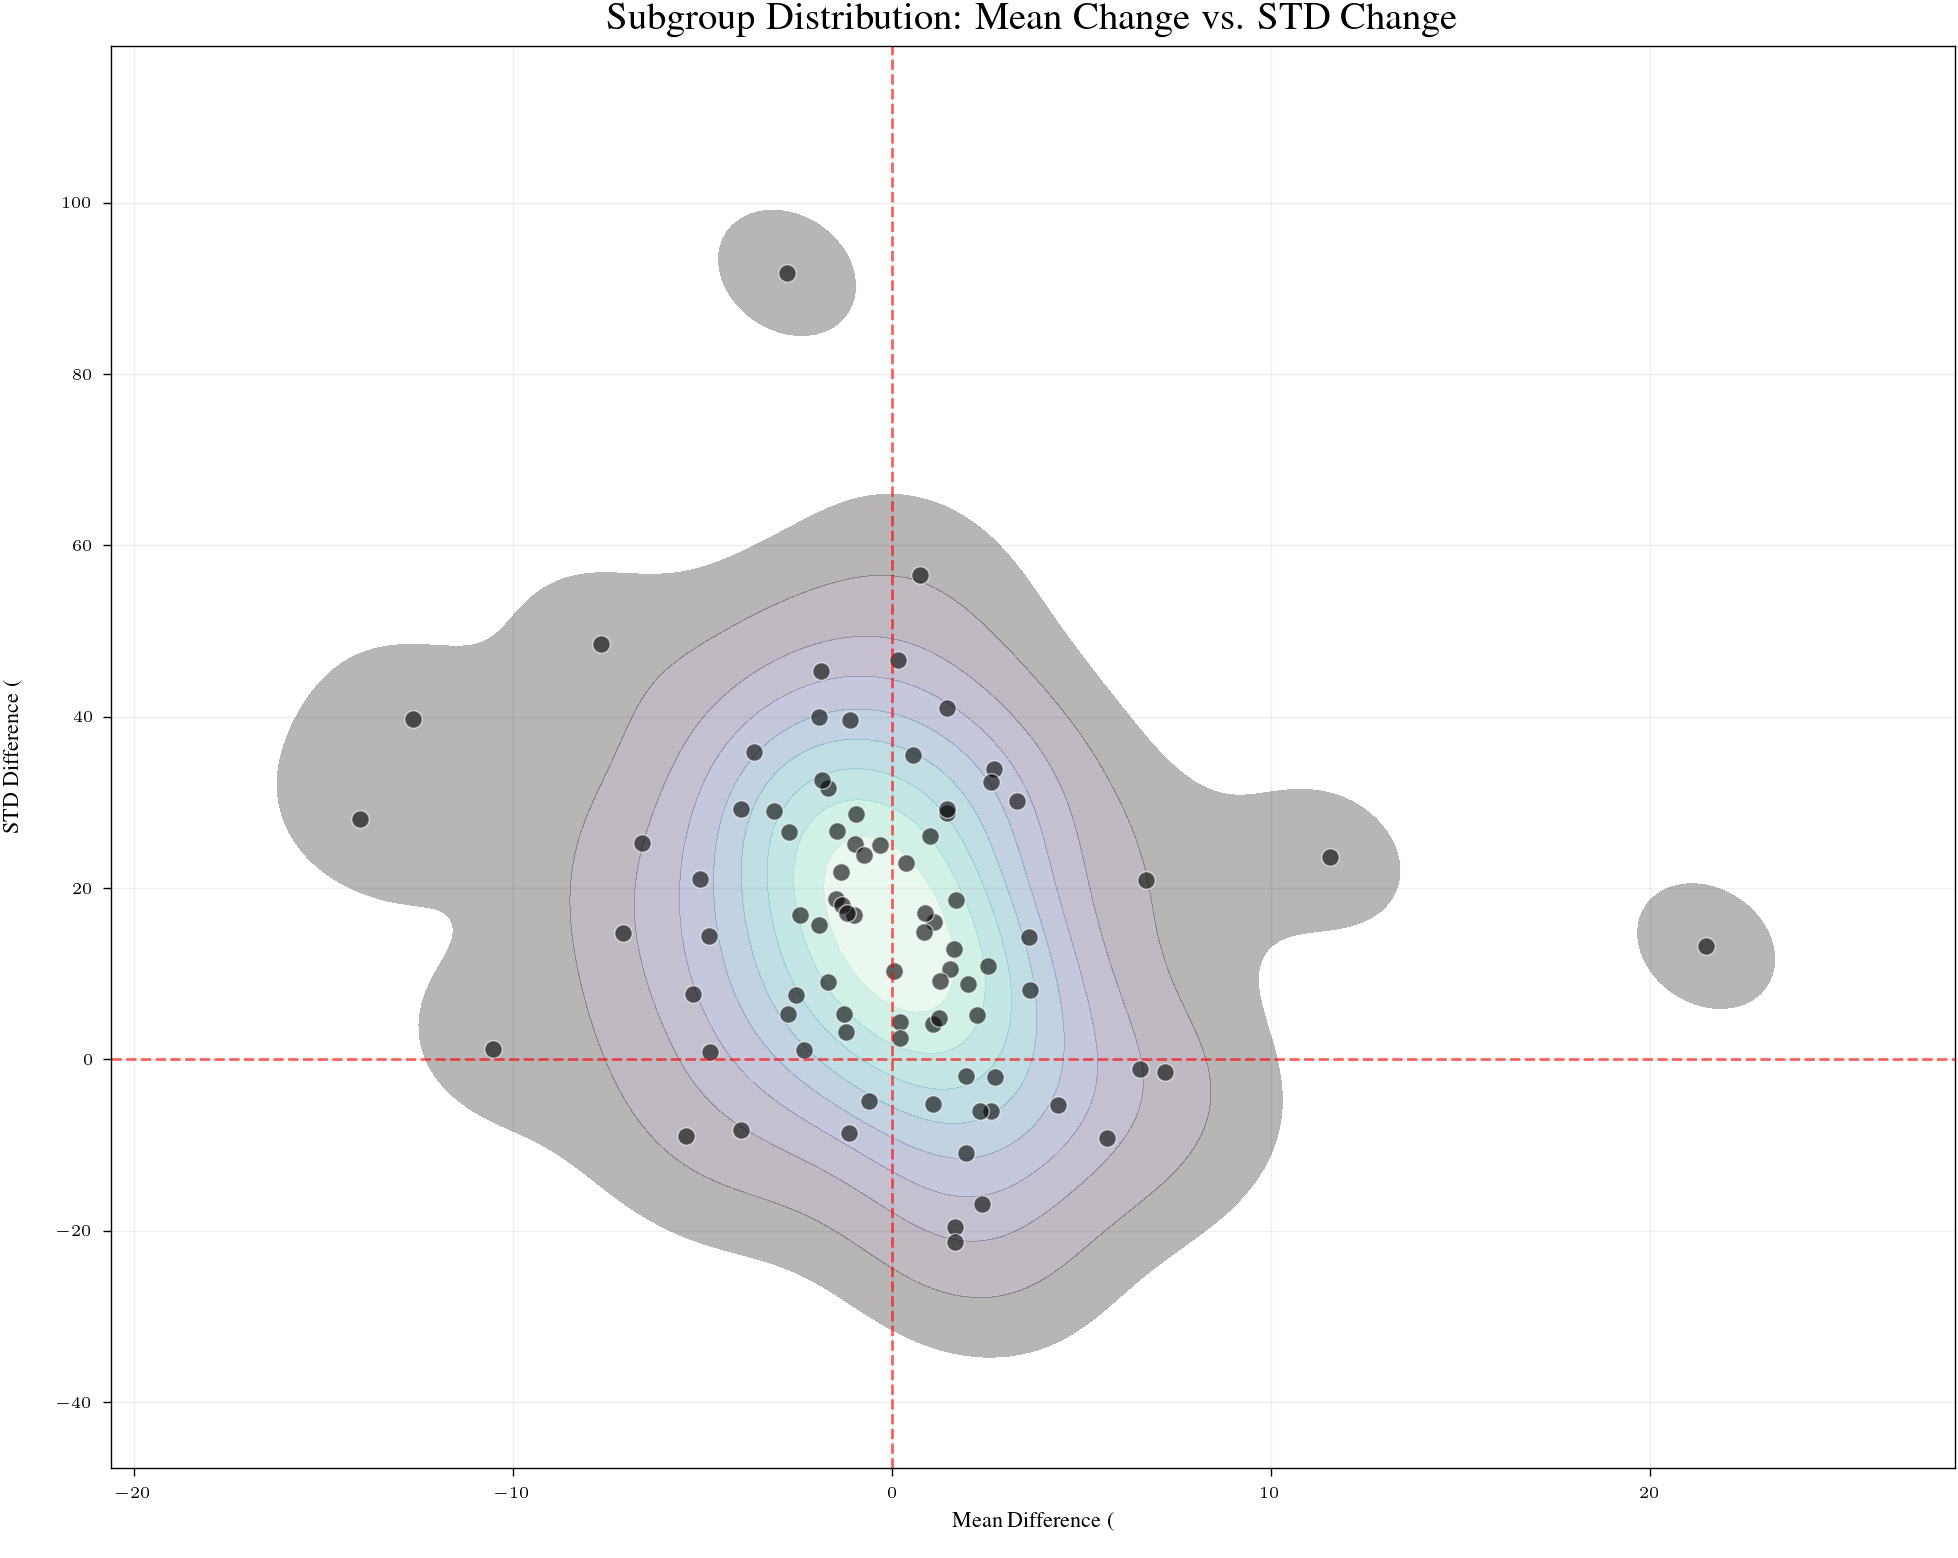

In [12]:


# --- 1. DATA PROCESSING ---
results_dis = []
grouped_dis = top_raw_all.groupby(["disziplin", "geschlecht", "altersklasse"])

for (dis, gender, ag), subgroup in grouped_dis:
    S_gr = subgroup.pivot_table(index="jahr", columns="rank", values="iaaf_score")
    
    # Selecting the two comparison windows
    start_vals = S_gr.loc[2001:2004].values.flatten()
    end_vals = S_gr.loc[2021:2024].values.flatten()

    s_pool = np.array(start_vals)[~np.isnan(start_vals)]
    e_pool = np.array(end_vals)[~np.isnan(end_vals)]

    if len(s_pool) > 8 and len(e_pool) > 8:
        # Statistics
        t_stat, p_mean = stats.ttest_ind(e_pool, s_pool, equal_var=False)
        _, p_std = stats.levene(e_pool, s_pool)
        
        # Cohen's d
        sd_pool = np.sqrt(((len(e_pool)-1)*np.var(e_pool, ddof=1) + (len(s_pool)-1)*np.var(s_pool, ddof=1)) / (len(e_pool)+len(s_pool)-2))
        d = (np.mean(e_pool) - np.mean(s_pool)) / sd_pool if sd_pool > 0 else 0
        
        results_dis.append({
            "Discipline": dis,
            "Gender": gender,
            "Age_Group": ag,
            "Mean_Diff_Perc": ((np.mean(e_pool) - np.mean(s_pool)) / np.mean(s_pool)) * 100,
            "STD_Diff_Perc": ((np.std(e_pool) - np.std(s_pool)) / np.std(s_pool)) * 100,
            "Cohen_d": d,
            "P_Value": p_mean
        })

df_dis = pd.DataFrame(results_dis)

# --- 2. PLOTTING ---
plt.figure(figsize=(10, 8))

# Background KDE Plot (Density Cloud)
sns.kdeplot(
    data=df_dis, x="Mean_Diff_Perc", y="STD_Diff_Perc",
    fill=True, alpha=0.3, cmap="mako", levels=10, thresh=0.05
)

# Scatter plot of all subgroups as points (No legend)
sns.scatterplot(
    data=df_dis, x="Mean_Diff_Perc", y="STD_Diff_Perc",
    alpha=0.6, s=40, color="black", legend=False
)

# Add Quadrant lines at 0
plt.axvline(0, color='red', linestyle='--', alpha=0.6, linewidth=1)
plt.axhline(0, color='red', linestyle='--', alpha=0.6, linewidth=1)

# Style adjustments
plt.title("Subgroup Distribution: Mean Change vs. STD Change", fontsize=14)
plt.xlabel("Mean Difference (%) \n")
plt.ylabel("STD Difference (%) \n")

plt.grid(alpha=0.2)
plt.tight_layout()
# plt.savefig("subgroup_kde_analysis.png")